# ASSIGNMENT  NLP- 2 (Sentiment Analysis )

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd

train_path = '/content/drive/MyDrive/job/Innomatics/tasks/gen_ai/task2/twitter_training.csv'
val_path = '/content/drive/MyDrive/job/Innomatics/tasks/gen_ai/task2/twitter_validation.csv'

# Define the column names
columns = ['ID', 'Entity', 'Sentiment', 'Text']

# Load the datasets
train_df = pd.read_csv(train_path, names=columns)
val_df = pd.read_csv(val_path, names=columns)

print("Data Loaded Successfully!")

Data Loaded Successfully!


Data Cleaning: Drop NaNs and "Irrelevant" labels

In [5]:
#drop Irrelevant and null cols

train_df = train_df[train_df['Sentiment'] != 'Irrelevant'].dropna(subset=['Text'])
val_df = val_df[val_df['Sentiment'] != 'Irrelevant'].dropna(subset=['Text'])

print(f"Training samples: {len(train_df)}")
print(train_df['Sentiment'].value_counts())

Training samples: 61121
Sentiment
Negative    22358
Positive    20655
Neutral     18108
Name: count, dtype: int64


In [8]:
train_df.head()

,ID,Entity,Sentiment,Text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [9]:
val_df.head()

,ID,Entity,Sentiment,Text
1,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
2,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
3,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
4,4433,Google,Neutral,Now the President is slapping Americans in the...
5,6273,FIFA,Negative,Hi @EAHelp I’ve had Madeleine McCann in my cel...


In [6]:
print(train_df[['Sentiment', 'Text']].sample(5))

      Sentiment                                               Text
18526  Positive                               Medal Groundbreaking
31634  Positive  I can't believe i'm saying this but, League of...
5399    Neutral  Toxic masculinity has me fully targeting “men’...
28451   Neutral                                                You
67977  Negative  People are upset over the @CyberpunkGame delay...


2. NLP Preprocessing

In [13]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download necessary NLTK data packets
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Initialize tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [14]:
def preprocess_text(text):
    # 1. Handle Special Characters & URLs (Regex)
    # Convert to string just in case, then lowercase
    text = str(text).lower()
    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # Remove user mentions (@user) and hashtags (#)
    text = re.sub(r'@\w+|#\w+', '', text)
    # Remove punctuation and numbers (keeping only a-z)
    text = re.sub(r'[^a-z\s]', '', text)

    # 2. Tokenization
    tokens = word_tokenize(text)

    # 3. Stopwords Removal & Lemmatization
    cleaned_tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]

    # 4. Join back into a single string for Vectorization
    return " ".join(cleaned_tokens)

In [15]:
print("Preprocessing started... this may take a minute.")
train_df['Cleaned_Text'] = train_df['Text'].apply(preprocess_text)
val_df['Cleaned_Text'] = val_df['Text'].apply(preprocess_text)
print("Preprocessing complete!")

Preprocessing started... this may take a minute.
Preprocessing complete!


In [16]:
# Compare raw vs cleaned text
print("Original:", train_df['Text'].iloc[5])
print("Cleaned: ", train_df['Cleaned_Text'].iloc[5])

Original: im getting into borderlands and i can murder you all,
Cleaned:  im getting borderland murder


3. Feature Engineering

In [17]:
from sklearn.feature_extraction.text import CountVectorizer

# Initialize CountVectorizer
# max_features=5000 limits the vocabulary to the top 5000 most frequent words to prevent memory issues
bow_vectorizer = CountVectorizer(max_features=5000)

X_train_bow = bow_vectorizer.fit_transform(train_df['Cleaned_Text'])
X_val_bow = bow_vectorizer.transform(val_df['Cleaned_Text'])

print(f"BoW Shape: {X_train_bow.shape}")

BoW Shape: (61121, 5000)


In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Fit and transform
X_train_tfidf = tfidf_vectorizer.fit_transform(train_df['Cleaned_Text'])
X_val_tfidf = tfidf_vectorizer.transform(val_df['Cleaned_Text'])

print(f"TF-IDF Shape: {X_train_tfidf.shape}")

TF-IDF Shape: (61121, 5000)


In [19]:
y_train = train_df['Sentiment']
y_test = val_df['Sentiment']

4. Model Building

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

# 1. Logistic Regression: Great for high-dimensional text data.
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_tfidf, y_train)

# 2. Multinomial Naive Bayes: The classic "baseline" for NLP.
# It calculates the probability of a word belonging to a class.
naive_bayes = MultinomialNB()
naive_bayes.fit(X_train_tfidf, y_train)

# 3. Decision Tree: Creates a tree of "if-then" rules based on word presence.
decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(X_train_tfidf, y_train)

print("All models have been trained successfully!")

All models have been trained successfully!


In [21]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_tfidf, y_train)

print("Random Forest trained!")

Random Forest trained!


5. Model Evaluation

In [22]:
from sklearn.metrics import accuracy_score, classification_report, f1_score

# Store results for final comparison
model_names = ["Logistic Regression", "Naive Bayes", "Decision Tree"]
trained_models = [log_reg, naive_bayes, decision_tree]
final_scores = {}

for name, model in zip(model_names, trained_models):
    y_pred = model.predict(X_val_tfidf)

    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    # Store for the table
    final_scores[name] = {"Accuracy": acc, "F1-Score": f1}

    print(f"\n{'='*20} {name} Evaluation {'='*20}")
    print(classification_report(y_test, y_pred))


==================== Logistic Regression Evaluation ====================
              precision    recall  f1-score   support

    Negative       0.81      0.89      0.85       266
     Neutral       0.90      0.77      0.83       285
    Positive       0.84      0.89      0.87       277

    accuracy                           0.85       828
   macro avg       0.85      0.85      0.85       828
weighted avg       0.85      0.85      0.85       828


==================== Naive Bayes Evaluation ====================
              precision    recall  f1-score   support

    Negative       0.70      0.84      0.77       266
     Neutral       0.83      0.60      0.70       285
    Positive       0.77      0.84      0.80       277

    accuracy                           0.76       828
   macro avg       0.77      0.76      0.76       828
weighted avg       0.77      0.76      0.76       828


==================== Decision Tree Evaluation ====================
              precision    rec

In [23]:
# Comparison table
comparison_df = pd.DataFrame(final_scores).T
print("\nFinal Performance Comparison:")
print(comparison_df.sort_values(by='F1-Score', ascending=False))


Final Performance Comparison:
                     Accuracy  F1-Score
Decision Tree        0.944444  0.944384
Logistic Regression  0.847826  0.847191
Naive Bayes          0.759662  0.755928


6. Comparison & Insights

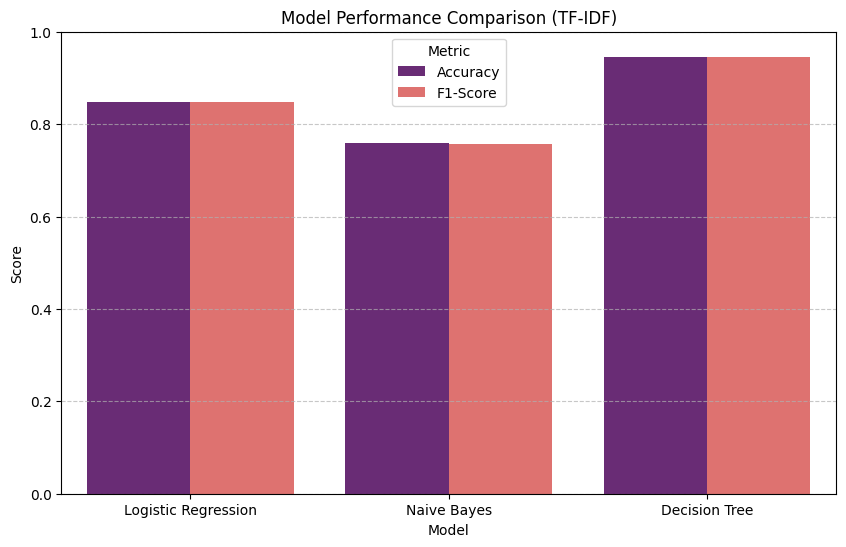

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

comparison_df = pd.DataFrame(final_scores).T.reset_index().rename(columns={'index': 'Model'})

melted_df = comparison_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(10, 6))
sns.barplot(data=melted_df, x="Model", y="Score", hue="Metric", palette="magma")
plt.title("Model Performance Comparison (TF-IDF)")
plt.ylim(0, 1.0) # Sets y-axis from 0 to 100%
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()